In [ ]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

Connet to the google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Read image and convert it to a torch tensor (channels, rows, columns) and display it.

torch.Size([3, 1031, 773])


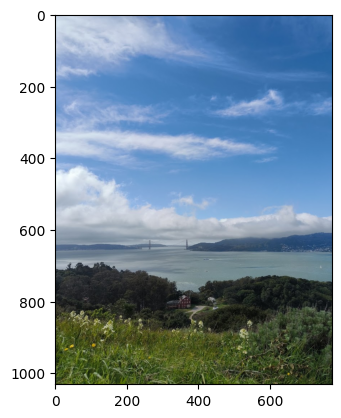

In [ ]:
img = torchvision.io.read_image('./drive/MyDrive/A_DL_2026/sf.jpg')
print(img.shape)
plt.imshow(img.permute(1,2,0))

Differnt padding schemes. Check https://pytorch.org/docs/stable/generated/torch.nn.functional.pad.html and try something else!

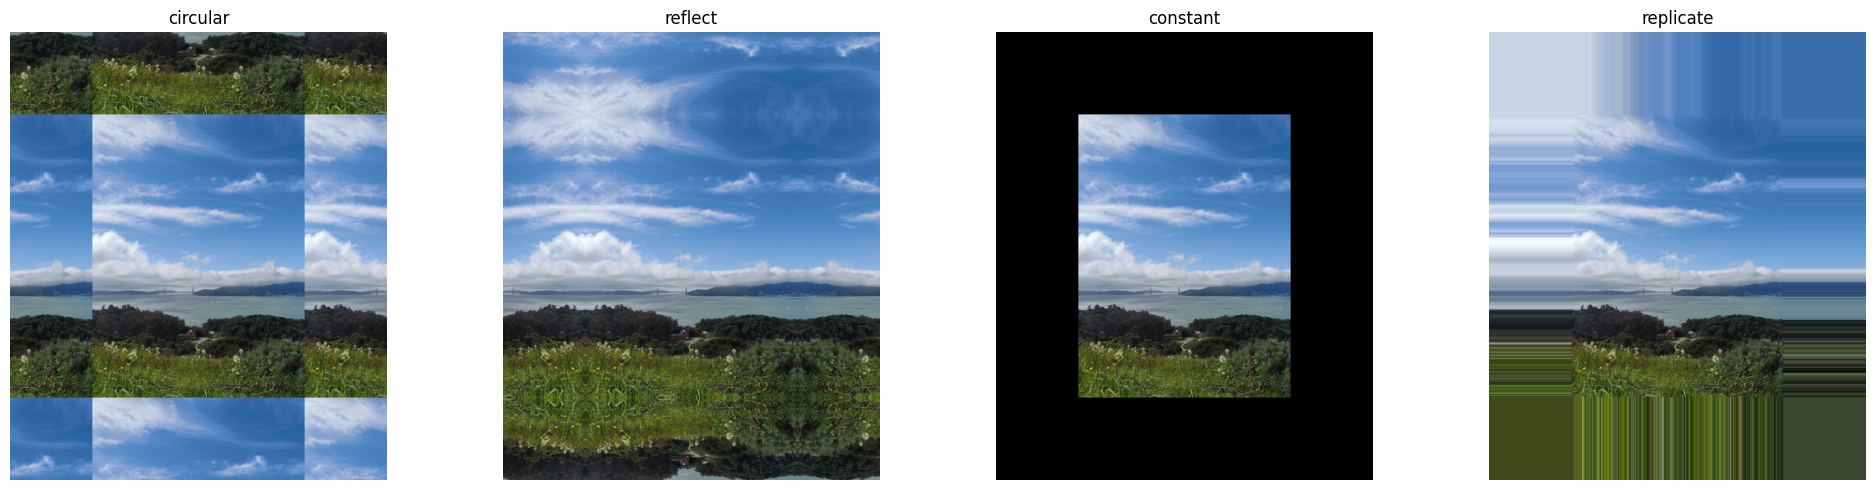

In [ ]:
padding_schemes = ["circular", "reflect", "constant", "replicate"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, scheme in zip(axes, padding_schemes):
    out = F.pad(img, (300, 300, 300, 300), mode=scheme)

    ax.imshow(out.permute(1, 2, 0))
    ax.set_title(scheme)
    ax.axis("off")

plt.tight_layout()
plt.show()

Convert the image to a grayscale for simplicty by averaging over the channel values

Original image shape:  torch.Size([3, 1031, 773])
Grey scale image:  torch.Size([1, 1031, 773])
Min. value = tensor(0.3333)
Max. value = tensor(252.3333)


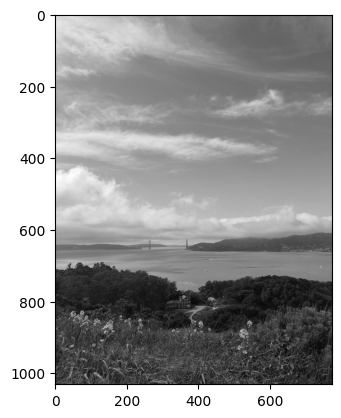

In [ ]:
# check if there a multiple channels (aka image is RGB)
if img.shape[0] > 1:
  grayscale_img = img.float().mean(dim=0, keepdim=True)

  print("Original image shape: ", img.shape)
  print("Grey scale image: ", grayscale_img.shape)

  # cmap = color map
  plt.imshow(grayscale_img.permute(1,2,0), cmap = 'gray')
  print('Min. value = ' + str(grayscale_img.min()))
  print('Max. value = ' + str(grayscale_img.max()))
else:
  grayscale_img = img.float()

Scale the image to range [0,1]

Note: if the relationship stays the same between the pixels when scaling the image will look the same

Min. value = tensor(0.0013)
Max. value = tensor(0.9895)
Tensor shape = torch.Size([1, 1031, 773])


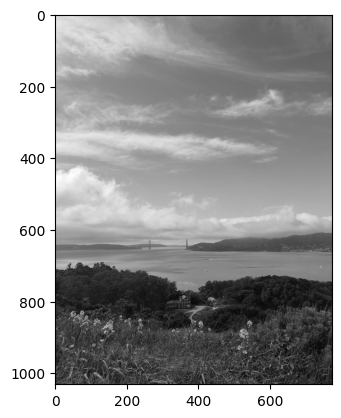

In [ ]:
grayscale_img_norm = grayscale_img / 255
plt.imshow(grayscale_img_norm.permute(1,2,0), cmap = 'gray')
print('Min. value = ' + str(grayscale_img_norm.min()))
print('Max. value = ' + str(grayscale_img_norm.max()))
print('Tensor shape = ' + str(grayscale_img_norm.shape))

In torch, the dimension should be (batch, channels, rows, columns), therefore, we add an empty dimension at location 0

In [ ]:
grayscale_img_norm_large = grayscale_img_norm.unsqueeze(0)
print('Tensor shape for orignial: ', grayscale_img_norm.shape)
print('Tensor shape = ' + str(grayscale_img_norm_large.shape))

Tensor shape for orignial:  torch.Size([1, 1031, 773])
Tensor shape = torch.Size([1, 1, 1031, 773])


We can also remove dimensions, if we need to

In [ ]:
grayscale_img_norm_small = grayscale_img_norm.squeeze(0)
print('Tensor shape for orignial: ', grayscale_img_norm.shape)
print('Tensor shape = ' + str(grayscale_img_norm_small.shape))

Tensor shape for orignial:  torch.Size([1, 1031, 773])
Tensor shape = torch.Size([1031, 773])


Initialize weights for a kernal/filter

1
[[[0.04 0.04 0.04 0.04 0.04]
  [0.04 0.04 0.04 0.04 0.04]
  [0.04 0.04 0.04 0.04 0.04]
  [0.04 0.04 0.04 0.04 0.04]
  [0.04 0.04 0.04 0.04 0.04]]]


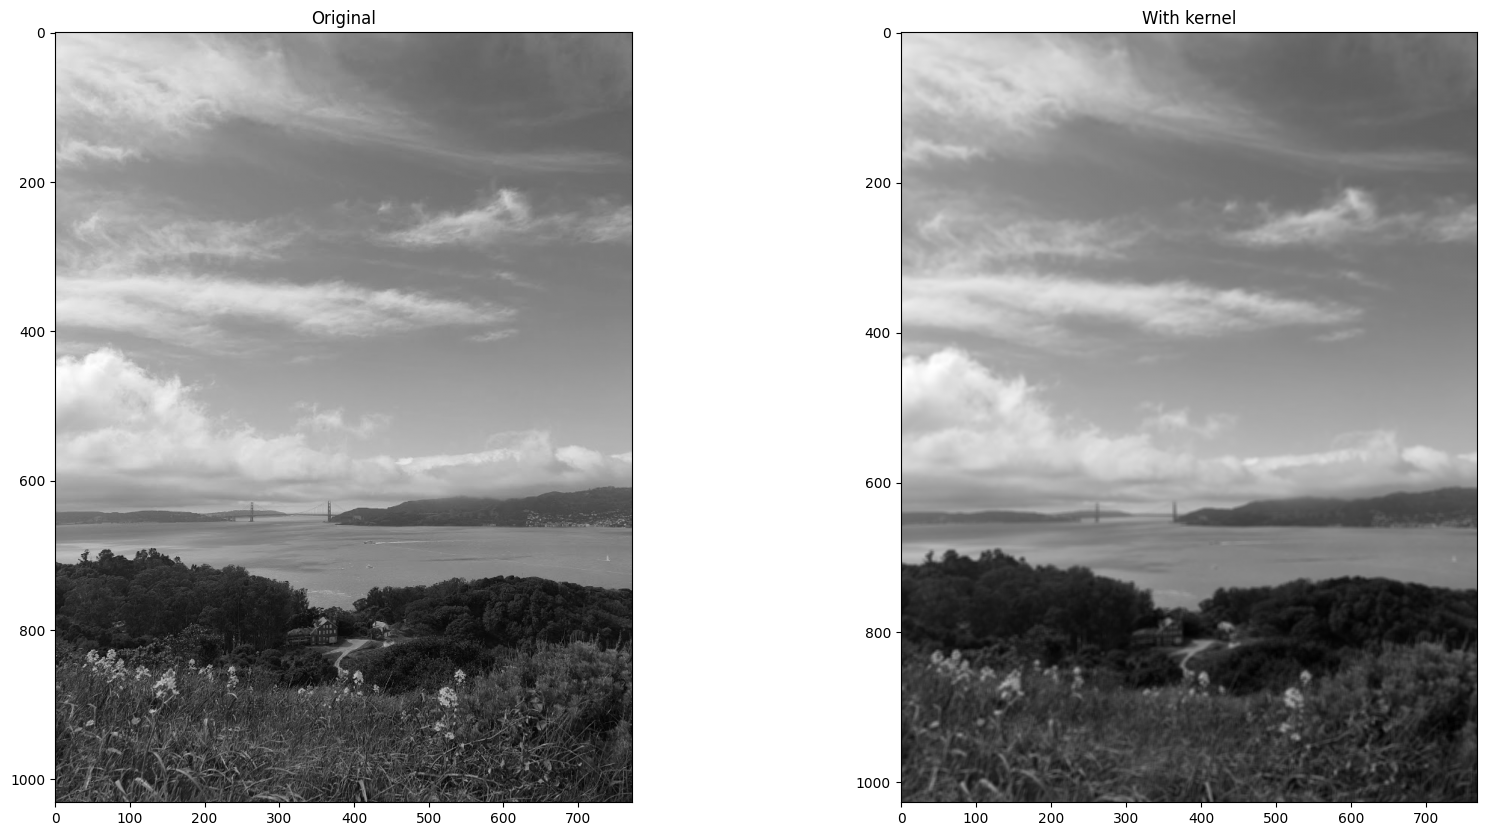

In [ ]:
# We want to create a kernel that is 1 x 5 x 5 - because we have a greyscale images.
print(grayscale_img_norm_large.shape[1])

w = np.ones((grayscale_img_norm_large.shape[1], 5, 5)) / (grayscale_img_norm_large.shape[1]*5*5)
w = w.astype(np.float32)

print(w)

weight = torch.from_numpy(w).unsqueeze(0)
result = torch.conv2d(grayscale_img_norm_large, weight)

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(grayscale_img_norm_large.squeeze(0).permute(1,2,0), cmap = 'gray')
plt.title("Original")
plt.subplot(1, 2, 2)
plt.title("With kernel")
plt.imshow(result.squeeze(0).permute(1,2,0), cmap = 'gray')



Make kernel to identify horizontal intensity changes

Text(0.5, 1.0, 'With kernel')

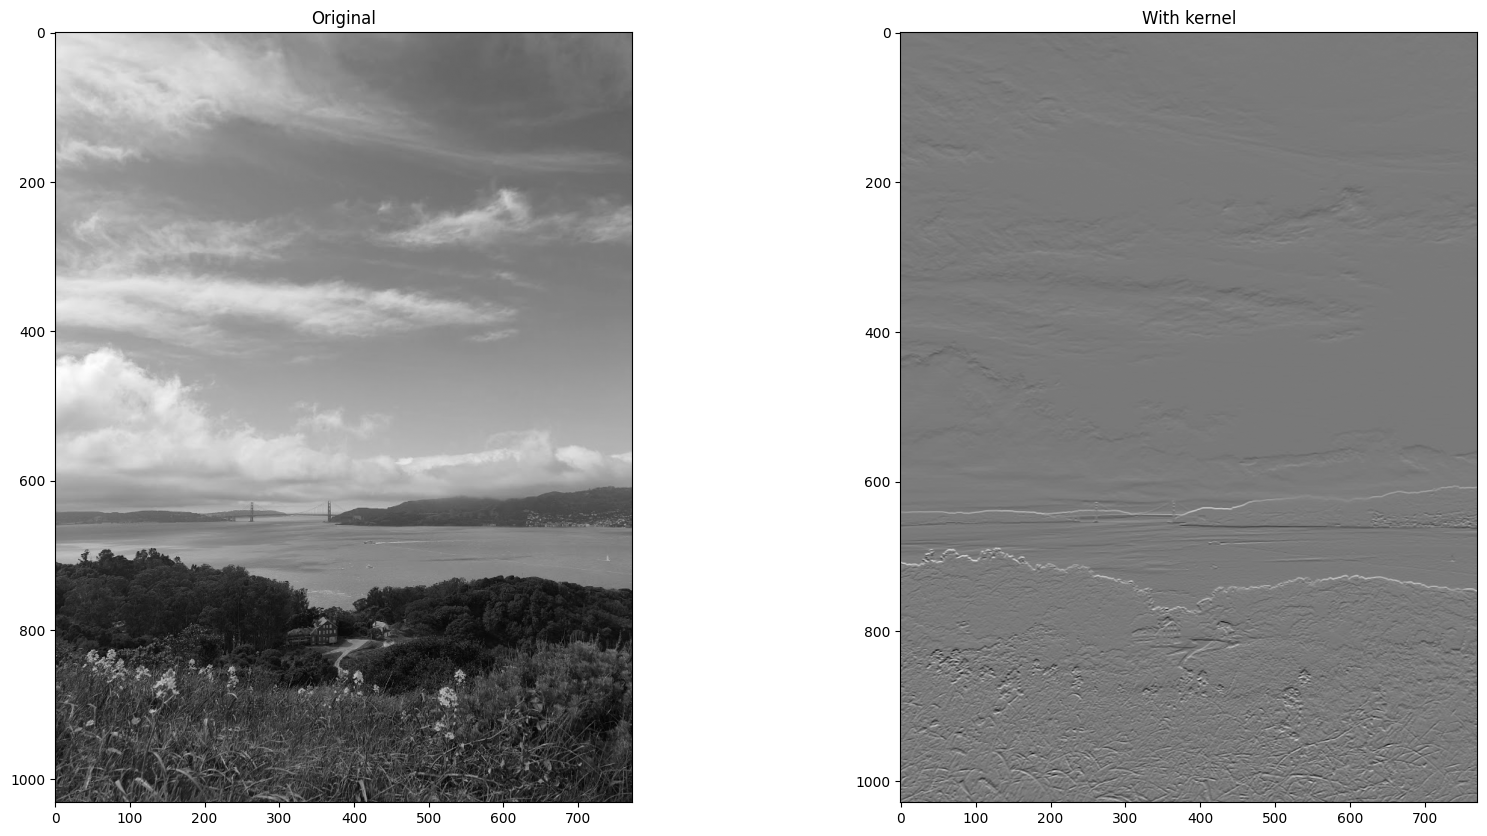

In [ ]:
w = np.array([
    [1., 0., -1.],
    [1., 0., -1.],
    [1., 0., -1.]
])

w = w.astype(np.float32).T
weight = torch.from_numpy(w).unsqueeze(0).unsqueeze(0)
result = torch.conv2d(grayscale_img_norm_large, weight)

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(grayscale_img_norm_large.squeeze(0).permute(1,2,0), cmap = 'gray')
plt.title("Original")
plt.subplot(1, 2, 2)
plt.imshow(result.squeeze(0).permute(1,2,0), cmap = 'gray')
plt.title("With kernel")




Text(0.5, 1.0, 'With kernel')

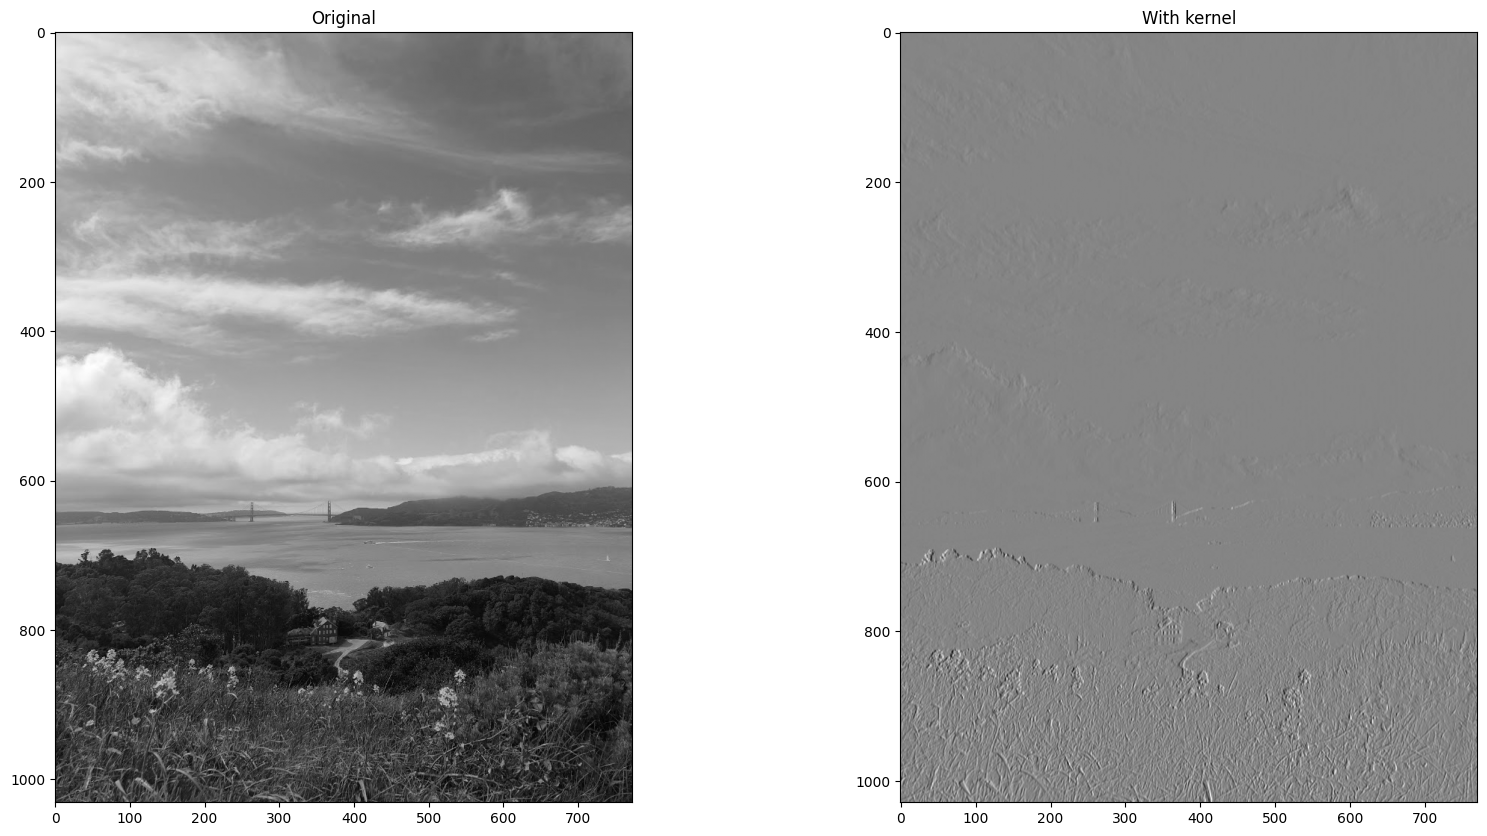

In [ ]:
w = np.array([
  [ 1.,   1.,   1. ],
  [ 0.,   0.,   0. ],
  [-1.,  -1.,  -1. ],
])

w = w.astype(np.float32).T
weight = torch.from_numpy(w).unsqueeze(0).unsqueeze(0)
result = torch.conv2d(grayscale_img_norm_large, weight)

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(grayscale_img_norm_large.squeeze(0).permute(1,2,0), cmap = 'gray')
plt.title("Original")
plt.subplot(1, 2, 2)
plt.imshow(result.squeeze(0).permute(1,2,0), cmap = 'gray')
plt.title("With kernel")
